[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HunterBushnell/SCP/blob/main/4_synapses.ipynb)

# SCP Step 4 - Synapse Tuning with BMTool

Tune chemical synapse mechanism parameters using BMTool's synaptic tuner with an SCP cell/tune directory.

Workflow:
1. Prepare an SCP cell/tune for BMTool.
2. Create or load `cell_configs/synapse_tuning_config.json`.
3. Select a configured synapse connection and initialize `SynapseTuner` with the SCP-built cell.
4. Use BMTool's single-event, interactive, frequency-response, and optional optimizer tools.
5. Print a copyable `syns.params` block for SCP synapse group configs.

This notebook intentionally stays close to BMTool's original synaptic tuner notebook. SCP-specific machinery is isolated in `modules.tuning.bmtool_synapse_adapter`, which passes BMTool a loader-neutral, cell-scoped `soma`/`all` facade; persistent tuning settings live in the tune-local Step 4 config.


## 4.0 Synapse Mechanism Setup

Step 4 requires the selected NEURON point process to be available before BMTool initializes. Built-in point processes need no MOD files; custom mechanisms use the directory configured by `paths.modfiles`.

Recommended workflow:
1. If you already have a custom synapse model, place its `.mod` file in the tune directory configured by `paths.modfiles` (normally `cells/<CELL>/tunes/<TUNE>/modfiles/`).
2. If you need a starting mechanism, use the cyneuro neuron mechanisms library: <https://github.com/cyneuro/neuron-mechanisms-library/tree/main/synaptic-mechanisms>.
3. For SCP examples, the recommended starting folder is the Blue Brain mechanisms folder: <https://github.com/cyneuro/neuron-mechanisms-library/tree/main/synaptic-mechanisms/blue-brain>.
4. Typical choices are:
   - excitatory synapse: `AMPA_NMDA.mod` or `AMPA_NMDA_STP.mod`,
   - inhibitory synapse: `GABA_A.mod` or `GABA_A_STP.mod`.
5. After adding or changing `.mod` files, restart the kernel if mechanisms were already loaded, then set `RECOMPILE_MODFILES = True` in section 4.1.

The mechanism name in `synapse_tuning_config.json` under `connections[*]["spec_settings"]["level_of_detail"]` must match the NEURON point-process name declared inside the `.mod` file, usually the filename without `.mod`.


In [1]:
# Environment setup: works locally or in Google Colab
# Autoreload is useful locally, but optional. Some hosted runtimes ship an
# IPython autoreload extension that is not compatible with their Python version.
try:
    ip = get_ipython()
except NameError:
    ip = None
if ip is not None:
    try:
        ip.run_line_magic("load_ext", "autoreload")
        ip.run_line_magic("autoreload", "2")
    except ModuleNotFoundError as exc:
        if getattr(exc, "name", None) == "imp":
            print("IPython autoreload is unavailable in this runtime; continuing without it.")
        else:
            raise
    except Exception as exc:
        print(f"IPython autoreload is unavailable ({exc}); continuing without it.")

import json
import os
import subprocess
import sys
from pathlib import Path

# User-editable only when running in a fresh Colab or unusual local layout.
SCP_REPO_URL = os.environ.get("SCP_REPO_URL", "https://github.com/HunterBushnell/SCP.git")
SCP_REPO_BRANCH = os.environ.get("SCP_REPO_BRANCH", "") or None
IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
AUTO_CLONE_REPO = os.environ.get("SCP_AUTO_CLONE", "1" if IN_COLAB else "0") not in {"0", "false", "False"}
INSTALL_DEPS = None  # None = install automatically in Colab, do not install locally.
SCP_REPO_DIR = Path(os.environ.get("SCP_REPO_DIR", "/content/SCP" if IN_COLAB else str(Path.cwd() / "SCP")))


def _looks_like_scp_repo(path: Path) -> bool:
    return (path / "modules").is_dir() and (path / "run_pipeline.py").is_file()


# Minimal pre-import bootstrap. Fresh Colab cannot import SCP helpers until the repo exists.
repo_root = None
env_root = os.environ.get("SCP_ROOT")
if env_root and _looks_like_scp_repo(Path(env_root).expanduser()):
    repo_root = Path(env_root).expanduser().resolve()
else:
    start = Path.cwd().resolve()
    candidates = list((start, *start.parents))
    for base in (start, start.parent):
        try:
            candidates.extend(child for child in base.iterdir() if child.is_dir())
        except Exception:
            pass
    for candidate in candidates:
        if _looks_like_scp_repo(candidate):
            repo_root = candidate.resolve()
            break

if repo_root is None:
    if not AUTO_CLONE_REPO:
        raise FileNotFoundError("Could not find SCP. Set SCP_ROOT or enable SCP_AUTO_CLONE=1.")
    clone_url = SCP_REPO_URL
    token = os.environ.get("SCP_GIT_TOKEN") or os.environ.get("SCP_GITHUB_TOKEN") or os.environ.get("GITHUB_TOKEN")
    if token and clone_url.startswith("https://") and "@" not in clone_url:
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    clone_cmd = ["git", "clone", "--depth", "1"]
    if SCP_REPO_BRANCH:
        clone_cmd += ["--branch", SCP_REPO_BRANCH]
    clone_cmd += [clone_url, str(SCP_REPO_DIR)]
    subprocess.check_call(clone_cmd)
    repo_root = SCP_REPO_DIR.resolve()

# Colab can preserve /content/SCP across notebook reloads/restarts. To avoid
# stale code, public notebooks refresh clean ephemeral Colab clones before
# importing SCP modules. Drive-backed clones, forks, branches, and tracked
# local edits are left untouched. Set SCP_AUTO_UPDATE=0 to disable this.
def _scp_repo_slug(url):
    url = str(url).strip()
    if url.endswith(".git"):
        url = url[:-4]
    if "github.com/" in url:
        return url.split("github.com/", 1)[1].lower()
    if url.startswith("git@github.com:"):
        return url.split(":", 1)[1].lower()
    return url.lower()

repo_root_text = str(repo_root)
is_ephemeral_colab_repo = repo_root_text.startswith("/content/") and not repo_root_text.startswith("/content/drive/")
auto_update_repo = os.environ.get("SCP_AUTO_UPDATE", "1") not in {"0", "false", "False"}
if IN_COLAB and auto_update_repo and is_ephemeral_colab_repo and (repo_root / ".git").is_dir():
    branch = SCP_REPO_BRANCH or "main"
    try:
        tracked_changes = subprocess.check_output(
            ["git", "status", "--porcelain", "--untracked-files=no"],
            cwd=str(repo_root),
            text=True,
        ).strip()
        current_branch = subprocess.check_output(
            ["git", "rev-parse", "--abbrev-ref", "HEAD"],
            cwd=str(repo_root),
            text=True,
        ).strip()
        origin_url = subprocess.check_output(
            ["git", "remote", "get-url", "origin"],
            cwd=str(repo_root),
            text=True,
        ).strip()
        if tracked_changes:
            print("SCP repo has tracked local changes; skipping automatic git update.")
        elif _scp_repo_slug(origin_url) != _scp_repo_slug(SCP_REPO_URL):
            print("SCP repo remote differs from SCP_REPO_URL; skipping automatic git update.")
        elif current_branch not in {branch, "HEAD"}:
            print(f"SCP repo is on branch {current_branch!r}; skipping automatic git update.")
        else:
            subprocess.check_call(["git", "fetch", "--depth", "1", "origin", branch], cwd=str(repo_root))
            subprocess.check_call(["git", "reset", "--hard", f"origin/{branch}"], cwd=str(repo_root))
            print(f"SCP repo updated to origin/{branch}.")
    except Exception as exc:
        print(f"Could not auto-update SCP repo ({exc}); continuing with local copy.")

os.environ["SCP_ROOT"] = str(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.notebooks.bootstrap import ensure_notebook_dependencies, ensure_python_package, is_colab

ensure_notebook_dependencies(install_deps=INSTALL_DEPS)
if INSTALL_DEPS is True or (INSTALL_DEPS is None and is_colab()):
    ensure_python_package("ipywidgets")
    ensure_python_package("tqdm")

print("Runtime:", "Colab" if is_colab() else "local")
print("SCP repo:", repo_root)
print("BMTool will be resolved after the configured mechanism and section are validated.")


Runtime: local
SCP repo: /home/hrbncv/SCP
BMTool will be resolved after the configured mechanism and section are validated.


## 4.1 Prepare SCP Cell

Choose the prepared tune that contains the post-synaptic cell to use for tuning.

Quick guide:
- `cell_name`: required folder under `cells/` when using the normal repo layout. No model is selected automatically.
- `tune_name`: tune folder under `cells/<cell>/tunes/`.
- `tune_dir_override`: optional direct path; leave `None` for normal repo layout.
- `RECOMPILE_MODFILES`: set `True` only when mechanism files changed.
- `LOAD_COMPILED_DLL`: normally `True`; set `False` only if another mechanism library is already loaded and you are managing NEURON state manually.


In [2]:
cell_name = "PV"  # REQUIRED unless tune_dir_override is set
tune_name = "tuned"
tunes_parent = "tunes"
tune_dir_override = None

RECOMPILE_MODFILES = False
LOAD_COMPILED_DLL = True

from modules.tuning import prepare_scp_synapse_tuning

session = prepare_scp_synapse_tuning(
    cell_name=cell_name,
    tune_name=tune_name,
    tunes_parent=tunes_parent,
    tune_dir_override=tune_dir_override,
    repo_root=repo_root,
    recompile_modfiles=RECOMPILE_MODFILES,
    load_compiled_dll=LOAD_COMPILED_DLL,
    resolve_bmtool=False,
)

cell = session.cell
tune_dir = session.tune_dir

print("Tune directory:", tune_dir)
print("Mechanisms:", json.dumps(session.mechanism_summary, indent=2))
print("Cell:", cell)


--No graphics will be displayed.
/home/hrbncv/miniconda3/envs/scp-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
na_ion mechanism not inserted in section axon[0]
NEURON: 
 near line 1
 forsec "axon" { ena = 53 }
                           ^
na_ion mechanism not inserted in section dend[0]
NEURON: 
 near line 1
 forsec "dend" { ena = 53 }
                           ^


Loaded Allen cell for 'PV' from /home/hrbncv/SCP/cells/PV/tunes/tuned/manifest.json, model_type='Biophysical - perisomatic', soma_diam_multiplier=6.0, Vinit=-71.0, loader=standard:Biophysical - perisomatic/allensdk_default
Tune directory: /home/hrbncv/SCP/cells/PV/tunes/tuned
Mechanisms: {
  "status": "ok",
  "modfiles_dir": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles",
  "compiled_dir": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles/x86_64",
  "dll": "/home/hrbncv/SCP/cells/PV/tunes/tuned/modfiles/x86_64/.libs/libnrnmech.so",
  "dll_sha256": "69138685b925aa86239d0b31fcffa0796e1c50c6fbc9bd9fa7290430e7141c5c",
  "compiled_now": false,
  "nrnivmodl": "/home/hrbncv/miniconda3/envs/scp-py311/bin/nrnivmodl",
  "loaded": true,
  "dll_preloaded": false
}
Cell: LoadedCell(label='PV', loader='allen_manifest')


## 4.2 Load Synapse Tuning Config

Create or load `cell_configs/synapse_tuning_config.json`. This file stores the BMTool-style `general_settings`, connection settings, default connection, slider variables, recorded variables, and optional optimizer defaults for the tune.

Quick guide:
- `OVERWRITE_SYNAPSE_TUNING_CONFIG`: leave `False` after the first run so manual edits are preserved.
- `CONNECTION_OVERRIDE`: leave `None` to use `default_connection` from the config, or set a connection key such as `"excitatory_facilitating"`.
- A newly generated config contains four neutral starting points and derives its holding voltage and temperature from `sim_config.conditions`.
- `general_settings`: BMTool protocol settings used by single-event and train checks.
- `connections[*].spec_settings.level_of_detail`: NEURON point-process mechanism name from the compiled modfiles.
- `connections[*].spec_settings.sec_id` / `sec_x`: section index and normalized section location for placing the test synapse.
- `connections[*].spec_syn_param`: mechanism parameters to initialize before tuning.


In [3]:
OVERWRITE_SYNAPSE_TUNING_CONFIG = False
CONNECTION_OVERRIDE = None  # None -> config default_connection; or a configured key

from modules.tuning import (
    connection_option,
    connection_settings_for_bmtool,
    ensure_synapse_tuning_config,
    general_settings_for_bmtool,
    optimizer_config,
    selected_connection,
)

synapse_config_path, synapse_tuning_config, synapse_config_status = ensure_synapse_tuning_config(
    tune_dir,
    overwrite=OVERWRITE_SYNAPSE_TUNING_CONFIG,
)

connection = selected_connection(synapse_tuning_config, CONNECTION_OVERRIDE)
general_settings = general_settings_for_bmtool(synapse_tuning_config)
conn_type_settings = connection_settings_for_bmtool(synapse_tuning_config)
connection_settings = conn_type_settings[connection]
current_name = synapse_tuning_config.get("current_name", "i")
slider_vars = connection_option(synapse_tuning_config, connection, "slider_vars")
other_vars_to_record = connection_option(synapse_tuning_config, connection, "other_vars_to_record")
step4_optimizer_config = optimizer_config(synapse_tuning_config)

print("Synapse tuning config:", synapse_config_path)
print("Config status:", synapse_config_status)
print("Available connections:", sorted(conn_type_settings))
print("Selected connection:", connection)
print("Mechanism:", connection_settings["spec_settings"].get("level_of_detail"))
print("Current name:", current_name)


Synapse tuning config: /home/hrbncv/SCP/cells/PV/tunes/tuned/cell_configs/synapse_tuning_config.json
Config status: existing
Available connections: ['Dep2PV', 'Inh2PV']
Selected connection: Dep2PV
Mechanism: AMPA_NMDA_STP
Current name: i


## 4.3 Initialize BMTool SynapseTuner

BMTool's original notebook initializes `SynapseTuner` with template and mechanism paths. In SCP, the adapter first validates the configured point process and canonical section index, then resolves optional BMTool and supplies the already-built cell through `hoc_cell`.

Quick guide:
- Leave `slider_vars` as `null` in `synapse_tuning_config.json` to use SCP defaults for the selected mechanism.
- Leave `other_vars_to_record` as `null` to record common mechanism-specific variables.
- Set either field in the config if your custom mechanism exposes different range variables.


In [4]:
from modules.tuning import (
    create_scp_synapse_tuner,
    default_record_vars_for_connection,
    default_slider_vars_for_connection,
)

resolved_slider_vars = slider_vars if slider_vars is not None else default_slider_vars_for_connection(connection_settings)
resolved_record_vars = (
    other_vars_to_record
    if other_vars_to_record is not None
    else default_record_vars_for_connection(connection_settings)
)

tuner = create_scp_synapse_tuner(
    session,
    conn_type_settings=conn_type_settings,
    connection=connection,
    general_settings=general_settings,
    current_name=current_name,
    other_vars_to_record=resolved_record_vars,
    slider_vars=resolved_slider_vars,
)

from modules.tuning import import_bmtool_synapse_api
_, SynapseOptimizer = import_bmtool_synapse_api(repo_root=repo_root)

print("Slider variables:", resolved_slider_vars)
print("Recorded synapse variables:", resolved_record_vars)


Slider variables: ['initW', 'Dep', 'Fac', 'Use', 'tau_r_AMPA', 'tau_d_AMPA', 'NMDA_ratio']
Recorded synapse variables: ['record_Pr', 'record_use']


## 4.4 Single Event

Run BMTool's single-event protocol. This is usually the first check before opening the interactive tuner.


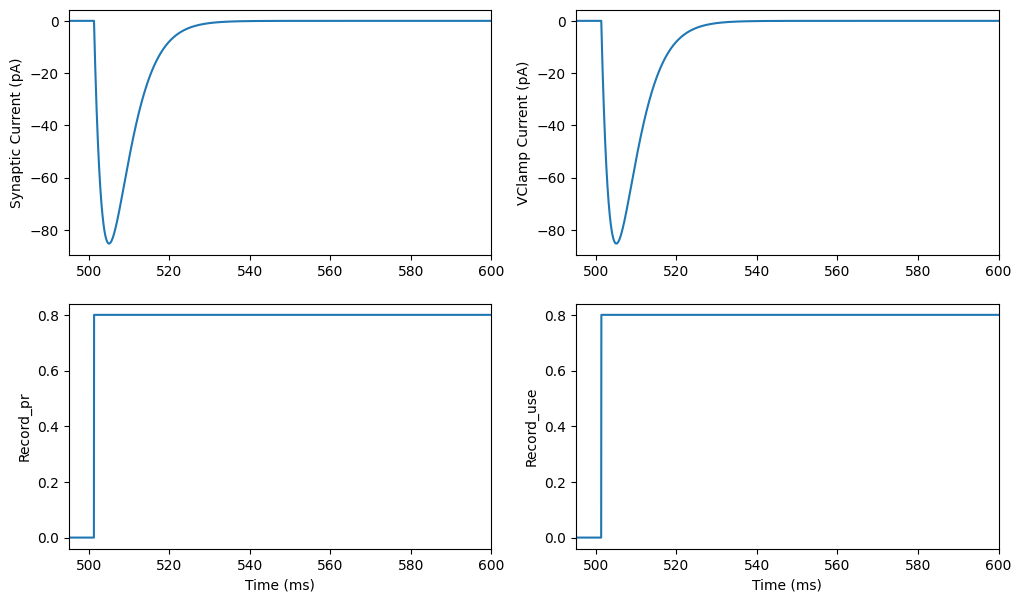

('baseline', 2.868052713722591e-05)
('sign', -1.0)
('latency', 1.35)
('amp', 0.08519789937120947)
('rise_time', 2.125)
('decay_time', 6.679188275010441)
('half_width', 10.5)
Current Integral in pA*ms: -885.03


In [5]:
tuner.SingleEvent()


## 4.5 Interactive Tuner

Open BMTool's interactive tuner. Use the sliders to inspect how parameter changes alter the single-event and train responses.


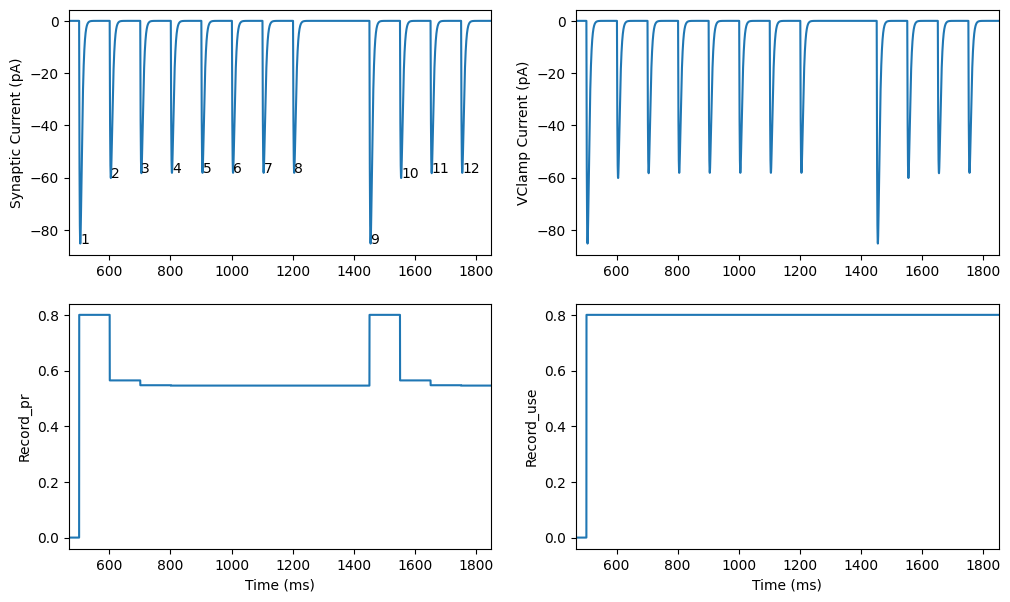


Short Term Plasticity Results for 10Hz with 250 Delay
PPR: Above 1 is facilitating, below 1 is depressing.
Induction: Above 0 is facilitating, below 0 is depressing.
Recovery: A measure of how fast STP decays.

Paired Pulse Response (PPR)
Calculation: 2nd pulse / 1st pulse
Values: ([[60.15]]) / ([[85.23]]) = [[0.71]]

Induction
Calculation: (avg(6th, 7th, 8th pulses) - 1st pulse) / max amps
Values: avg([[58.16, 58.16, 58.16]]) - [[85.23]] / [85.23]
([58.16]) - ([85.23]) / [85.23] = -0.318

Recovery
Calculation: (avg(9th, 10th, 11th, 12th pulses) - avg(1st to 4th pulses)) / max amps
Values: avg([[85.23, 60.15, 58.31, 58.17]]) - avg([[85.23, 60.15, 58.31, 58.17]]) / [85.23]
([65.46]) - ([65.46]) / [85.23] = 0.000




In [6]:
tuner.InteractiveTuner()


## 4.6 Frequency Response

Run BMTool's short-term plasticity frequency-response helper. This reports paired-pulse ratio, induction, and recovery across stimulation frequencies.


In [7]:
results = tuner.stp_frequency_response(log_plot=False)
results


Analyzing frequencies:   0%|          | 0/16 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 4.7 Optional SynapseOptimizer

BMTool can also optimize selected mechanism parameters toward target metrics. Treat this as optional; manual tuning with the interactive tuner is often easier to reason through first.

Optimizer defaults live in `synapse_tuning_config.json` under `optimizer`.

Quick guide:
- `optimizer.enabled`: set `true` in the config, or set `RUN_OPTIMIZER = True` below, to run this cell.
- `optimizer.param_bounds`: parameters and search bounds for the selected mechanism.
- `optimizer.target_metrics`: desired BMTool metrics.
- `optimizer.cost_weights`: relative weights for metric errors.


In [ ]:
RUN_OPTIMIZER = bool(step4_optimizer_config.get("enabled", False))

optimizer = SynapseOptimizer(tuner)

param_bounds = {
    name: tuple(bounds)
    for name, bounds in (step4_optimizer_config.get("param_bounds") or {}).items()
    if hasattr(tuner.syn, name)
}
target_metrics = dict(step4_optimizer_config.get("target_metrics") or {})
cost_weights = dict(step4_optimizer_config.get("cost_weights") or {})


def weighted_metric_cost(metrics, targets):
    total = 0.0
    for metric_name, weight in cost_weights.items():
        if metric_name in metrics and metric_name in targets:
            total += float(weight) * (metrics[metric_name] - targets[metric_name]) ** 2
    return total


if RUN_OPTIMIZER:
    if not param_bounds:
        raise ValueError("No optimizer parameters match the selected mechanism. Update optimizer.param_bounds.")
    if not target_metrics:
        raise ValueError("No optimizer target metrics configured. Update optimizer.target_metrics.")

    result = optimizer.optimize_parameters(
        target_metrics=target_metrics,
        param_bounds=param_bounds,
        run_single_event=bool(step4_optimizer_config.get("run_single_event", True)),
        run_train_input=bool(step4_optimizer_config.get("run_train_input", True)),
        train_frequency=step4_optimizer_config.get("train_frequency", 50),
        train_delay=step4_optimizer_config.get("train_delay", 250),
        init_guess=step4_optimizer_config.get("init_guess", "random"),
        cost_function=weighted_metric_cost,
        method=step4_optimizer_config.get("method", "SLSQP"),
    )
    optimizer.plot_optimization_results(result)
else:
    result = None
    print("Optimizer skipped. Set optimizer.enabled=true in synapse_tuning_config.json or RUN_OPTIMIZER=True to run it.")

result


## 4.8 Export Tuned Parameters for SCP

After manual tuning or optimization, print a copyable `syns.params` block. Paste these values into the relevant `cells/<cell>/tunes/<tune>/cell_configs/syn_groups/*.json` file when you are ready to keep the tuned parameters.

This cell does not edit config files automatically.


In [ ]:
from modules.tuning import get_tuned_synapse_params, print_syn_group_param_block

tuned_params = get_tuned_synapse_params(tuner)
print_syn_group_param_block(tuned_params)


## Extra Notes

- Restart the kernel if NEURON reports that a different mechanism library is already loaded.
- If a slider variable is missing, confirm the selected mechanism exposes that parameter in its `.mod` file.
- For custom SCP models, keep the BMTool dictionary structure the same and change only the mechanism name, section location, and parameter names.
